# YOLO v1 디버그 (전처리 데이터 전용)

이 노트북의 목적: 전처리 완료 데이터 기준 10 epoch 디버그 학습 실행.

- 공식 지표 산출: `src/evaluation/evaluation.py` 공통 평가 사용
- 참고용 지표 산출: Ultralytics 기본 YOLO 평가 사용
- 베스트 가중치 파일명 규칙: `{MODEL_NAME}_best.pt`
- 전처리 파이프라인 산출물 기준 `data.yaml` 사용
- PROJECT_ROOT: /content/drive/MyDrive/pill_detection_project (생성되는 결과물은 로컬과 동일한 환경(폴더명) 세팅)
- DATA_DIR: /content/drive/MyDrive/data/초급_프로젝트/dataset (팀 공통 경로)


In [1]:
IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    print('Colab mode: Drive mounted')
else:
    print('Local mode: google.colab not available, skip Drive mount')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab mode: Drive mounted


- 경로 및 기본 세팅

In [ ]:
import os
import sys
import json
import shutil
import datetime as dt
import subprocess
from pathlib import Path

from IPython.display import display

# Colab/로컬 공통 프로젝트 루트 결정
if 'IN_COLAB' not in globals():
    IN_COLAB = False

PROJECT_ROOT = Path('/content/drive/MyDrive/pill_detection_project')  # 사용자 고정 경로
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f'PROJECT_ROOT not found: {PROJECT_ROOT}' + '\n' +
        'Mount Drive first and verify folder path.'
    )
IN_COLAB = os.path.exists('/content') and str(PROJECT_ROOT).startswith('/content/')


SRC_DIR = PROJECT_ROOT / 'src'

# 팀 공통 데이터셋 경로 후보 설정
TEAM_DATA_DIR_CANDIDATES = [
    Path('/content/drive/MyDrive/data/초급_프로젝트/dataset'),
    Path('/content/drive/MyDrive/data/초급_프로젝트_/dataset'),
]

DATA_DIR = None
for cand in TEAM_DATA_DIR_CANDIDATES:
    if cand.exists():
        DATA_DIR = cand
        break

if DATA_DIR is None:
    DATA_DIR = TEAM_DATA_DIR_CANDIDATES[0]

DATA_YAML = DATA_DIR / 'data.yaml'
TRAIN_JSON = DATA_DIR / 'train_letterbox.json'
VAL_JSON = DATA_DIR / 'val_letterbox.json'
VAL_IMAGE_DIR = DATA_DIR / 'letterbox_images' / 'val'

MODELS_DIR = PROJECT_ROOT / 'models' / 'yolo'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'yolo'
RUNS_DIR = MODELS_DIR / 'runs'

MODEL_NAME = 'yolov8s_v1'
WEIGHTS = 'yolov8s.pt'
EPOCHS = 10
IMGSZ = 800
BATCH = 16
PATIENCE = 10
# Ultralytics 라벨 탐색 규칙 대응 설정
# 팀 산출물 원본 유지 및 이미지 폴더 라벨 미러링 적용
SYNC_LABELS_FOR_ULTRALYTICS = True

# Ultralytics 기본 증강 비활성화 설정
YOLO_AUGMENT = False
YOLO_HSV_H = 0.0
YOLO_HSV_S = 0.0
YOLO_HSV_V = 0.0
YOLO_DEGREES = 0.0
YOLO_TRANSLATE = 0.0
YOLO_SCALE = 0.0
YOLO_SHEAR = 0.0
YOLO_PERSPECTIVE = 0.0
YOLO_FLIPUD = 0.0
YOLO_FLIPLR = 0.0
YOLO_MOSAIC = 0.0
YOLO_MIXUP = 0.0
YOLO_COPY_PASTE = 0.0


# 산출물 누락 시 자동 전처리 실행 설정
AUTO_PREPROCESS_IF_MISSING = False
# 팀 전처리 파이프라인 전체 사용 설정
USE_ALL_PREPROCESSING_FILES = True
# 전처리 산출물 강제 재생성 설정
FORCE_REBUILD_PREPROCESSING = False

# evaluation_use.ipynb 형식 에폭 루프 평가 설정
RUN_COMMON_EVAL_EACH_EPOCH = True
SAVE_PERIOD = 1

CONF_THRESHOLD = 0.25
PR_IOU_THRESHOLD = 0.5
NMS_IOU = 0.7
PREDICT_CONF_FOR_COMMON_EVAL = 0.001  # keep low to avoid empty predictions

for p in [MODELS_DIR, RESULTS_DIR, RUNS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f'PROJECT_ROOT not found: {PROJECT_ROOT}' + '\n' +
        'Set PROJECT_ROOT manually in this cell.'
    )

if not SRC_DIR.exists():
    raise FileNotFoundError(
        f'SRC_DIR not found: {SRC_DIR}' + '\n' +
        'PROJECT_ROOT must contain src/ and run_preprocessing.py.'
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f'IN_COLAB: {IN_COLAB}')
print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DATA_DIR: {DATA_DIR}')
print(f'MODEL_NAME: {MODEL_NAME}')
print(f'EPOCHS: {EPOCHS}')


IN_COLAB: True
PROJECT_ROOT: /content/drive/MyDrive/pill_detection_project
DATA_DIR: /content/drive/MyDrive/data/초급_프로젝트/dataset
MODEL_NAME: yolov8s_v1
EPOCHS: 10


- 라이브러리

In [3]:
import sys
from pathlib import Path
# 이전 셀 미실행 상황 대응 경로 부트스트랩
if 'PROJECT_ROOT' not in globals():
    PROJECT_ROOT = Path('/content/drive/MyDrive/pill_detection_project')
if 'SRC_DIR' not in globals():
    SRC_DIR = PROJECT_ROOT / 'src'

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import importlib
import re

REQ_PATH = PROJECT_ROOT / 'requirements.txt'

def _pip_install(args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])

def _base_pkg_name(spec):
    return re.split(r'[<>=!~]+', spec, maxsplit=1)[0].strip()

if REQ_PATH.exists():
    print(f'Installing from requirements (Colab-safe): {REQ_PATH}')
    lines = REQ_PATH.read_text(encoding='utf-8').splitlines()
    specs = []
    for ln in lines:
        s = ln.strip()
        if not s or s.startswith('#'):
            continue
        # Colab 기본 torch 환경 유지 목적 버전 고정 패키지 제외
        if s.startswith('torch==') or s.startswith('torchvision==') or s.startswith('torchaudio=='):
            print(f'Skip torch pin for Colab: {s}')
            continue
        specs.append(s)

    failed_specs = []
    for spec in specs:
        try:
            _pip_install([spec])
        except subprocess.CalledProcessError:
            base = _base_pkg_name(spec)
            print(f'Pinned install failed -> fallback unpinned: {spec} -> {base}')
            try:
                _pip_install([base])
            except subprocess.CalledProcessError:
                failed_specs.append(spec)

    if failed_specs:
        print('Some requirements still failed:', failed_specs)
else:
    print('requirements.txt not found. Skipping requirements install.')

# 핵심 YOLO 의존성 설치
_pip_install(['ultralytics', 'pycocotools'])

import pandas as pd
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 공통 평가 함수 원본 호출 사용
from src.evaluation.evaluation import (
    evaluate_all,
    convert_yolo_results,
    init_history,
    update_history,
    save_history,
    load_history,
    plot_training_history,
)

def _pick_col(df, names, default=0.0):
    for n in names:
        if n in df.columns:
            return df[n].fillna(default).astype(float).tolist()
    return [float(default)] * len(df)

def build_history_from_yolo_results(results_csv_path):
    df = pd.read_csv(results_csv_path)
    if len(df) == 0:
        raise ValueError(f'Empty YOLO results CSV: {results_csv_path}')

    train_box = _pick_col(df, ['train/box_loss'])
    train_cls = _pick_col(df, ['train/cls_loss'])
    train_dfl = _pick_col(df, ['train/dfl_loss'])
    val_box = _pick_col(df, ['val/box_loss'])
    val_cls = _pick_col(df, ['val/cls_loss'])
    val_dfl = _pick_col(df, ['val/dfl_loss'])

    train_loss = [a + b + c for a, b, c in zip(train_box, train_cls, train_dfl)]
    val_loss = [a + b + c for a, b, c in zip(val_box, val_cls, val_dfl)]

    precision = _pick_col(df, ['metrics/precision(B)', 'metrics/precision'])
    recall = _pick_col(df, ['metrics/recall(B)', 'metrics/recall'])
    map50 = _pick_col(df, ['metrics/mAP50(B)', 'metrics/mAP_0.5(B)', 'metrics/mAP50'])
    map5095 = _pick_col(df, ['metrics/mAP50-95(B)', 'metrics/mAP_0.5:0.95(B)', 'metrics/mAP50-95'])

    history = init_history()
    for idx in range(len(df)):
        metrics = {
            'mAP@50': float(map50[idx]),
            'mAP@75:95': float(map5095[idx]),
            'precision': float(precision[idx]),
            'recall': float(recall[idx]),
        }
        update_history(
            history,
            epoch=idx + 1,
            train_loss=float(train_loss[idx]),
            val_loss=float(val_loss[idx]),
            metrics=metrics,
        )
    return history, df

env_info = {
    'timestamp': dt.datetime.now().isoformat(),
    'python': sys.version,
    'torch': torch.__version__,
    'cuda_available': bool(torch.cuda.is_available()),
    'device_count': int(torch.cuda.device_count()),
    'ultralytics': importlib.import_module('ultralytics').__version__,
    'model_name': MODEL_NAME,
    'weights': WEIGHTS,
    'epochs': EPOCHS,
    'imgsz': IMGSZ,
    'batch': BATCH,
}

ENV_JSON = RESULTS_DIR / f'env_{MODEL_NAME}.json'
with open(ENV_JSON, 'w', encoding='utf-8') as f:
    json.dump(env_info, f, ensure_ascii=False, indent=2)

print(f'Environment metadata saved: {ENV_JSON}')


Installing from requirements (Colab-safe): /content/drive/MyDrive/pill_detection_project/requirements.txt
Skip torch pin for Colab: torch==2.7.1+cu118
Skip torch pin for Colab: torchvision==0.22.1+cu118
Skip torch pin for Colab: torchaudio==2.7.1+cu118
Environment metadata saved: /content/drive/MyDrive/pill_detection_project/results/yolo/env_yolov8s_v1.json


# 전처리

In [ ]:
import sys
from pathlib import Path
# 이전 셀 미실행 상황 대응 경로 부트스트랩
if 'PROJECT_ROOT' not in globals():
    PROJECT_ROOT = Path('/content/drive/MyDrive/pill_detection_project')
if 'SRC_DIR' not in globals():
    SRC_DIR = PROJECT_ROOT / 'src'

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

required_artifacts_core = [
    DATA_YAML,
    TRAIN_JSON,
    VAL_JSON,
    DATA_DIR / 'letterbox_images' / 'train',
    VAL_IMAGE_DIR,
    DATA_DIR / 'yolo_labels' / 'train',
    DATA_DIR / 'yolo_labels' / 'val',
]

missing_artifacts = [p for p in required_artifacts_core if not p.exists()]
if missing_artifacts:
    print('Missing artifacts detected:')
    for p in missing_artifacts:
        print(' -', p)

if missing_artifacts and AUTO_PREPROCESS_IF_MISSING:
    run_preprocess_script = PROJECT_ROOT / 'run_preprocessing.py'
    if not run_preprocess_script.exists():
        raise FileNotFoundError(f'run_preprocessing.py not found: {run_preprocess_script}')

    print('Run team preprocessing pipeline (as-is): run_preprocessing.py')
    proc = subprocess.run(
        [sys.executable, str(run_preprocess_script)],
        cwd=str(PROJECT_ROOT),
        text=True,
        capture_output=True,
    )

    if proc.stdout:
        print('--- run_preprocessing.py stdout (tail) ---')
        print(proc.stdout[-4000:])
    if proc.stderr:
        print('--- run_preprocessing.py stderr (tail) ---')
        print(proc.stderr[-4000:])

    if proc.returncode != 0:
        raise RuntimeError(
            f'run_preprocessing.py failed with exit code {proc.returncode}. ' +
            'See stdout/stderr tail printed above for exact cause.'
        )

missing_after = [p for p in required_artifacts_core if not p.exists()]
if missing_after:
    raise FileNotFoundError('Artifacts still missing after preprocessing:\\n' + '\\n'.join(str(p) for p in missing_after))

print('Preprocessed artifacts are ready.')
print(f'Artifacts location: {DATA_DIR}')
print(f'DATA_YAML: {DATA_YAML}')
print(f'TRAIN_JSON: {TRAIN_JSON}')
print(f'VAL_JSON: {VAL_JSON}')
print(f'VAL_IMAGE_DIR: {VAL_IMAGE_DIR}')

if SYNC_LABELS_FOR_ULTRALYTICS:
    for split in ['train', 'val']:
        src_lbl_dir = DATA_DIR / 'yolo_labels' / split
        dst_img_dir = DATA_DIR / 'letterbox_images' / split
        if not src_lbl_dir.exists() or not dst_img_dir.exists():
            raise FileNotFoundError(f'Label sync path missing: {src_lbl_dir} or {dst_img_dir}')

        copied = 0
        for lbl_path in src_lbl_dir.glob('*.txt'):
            dst = dst_img_dir / lbl_path.name
            shutil.copy2(lbl_path, dst)
            copied += 1

        print(f'Label sync ({split}): {copied} txt -> {dst_img_dir}')

    # YOLO 스캔 로그용 라벨 개수 점검
    n_train_lbl = len(list((DATA_DIR / 'letterbox_images' / 'train').glob('*.txt')))
    n_val_lbl = len(list((DATA_DIR / 'letterbox_images' / 'val').glob('*.txt')))
    print(f'Ultralytics-readable labels: train={n_train_lbl}, val={n_val_lbl}')



# 현재 데이터 경로 기준 data.yaml 정규화
try:
    import yaml
    with open(DATA_YAML, 'r', encoding='utf-8') as f:
        ycfg = yaml.safe_load(f) or {}

    expected_path = str(DATA_DIR)
    changed = False

    if ycfg.get('path') != expected_path:
        ycfg['path'] = expected_path
        changed = True

    # YOLO 표준 상대경로 유지
    if ycfg.get('train') != 'letterbox_images/train':
        ycfg['train'] = 'letterbox_images/train'
        changed = True
    if ycfg.get('val') != 'letterbox_images/val':
        ycfg['val'] = 'letterbox_images/val'
        changed = True

    if changed:
        with open(DATA_YAML, 'w', encoding='utf-8') as f:
            yaml.safe_dump(ycfg, f, allow_unicode=True, sort_keys=False)
        print(f'Normalized DATA_YAML path/subpaths -> {DATA_YAML}')
    else:
        print('DATA_YAML already normalized.')
except Exception as e:
    print(f'Warning: DATA_YAML normalization skipped: {e}')
from src.preprocessing.dataset import validate_coco, build_df_from_json
validate_coco(str(TRAIN_JSON), target_size=IMGSZ)
validate_coco(str(VAL_JSON), target_size=IMGSZ)
df_train_preview = build_df_from_json(str(TRAIN_JSON), str(DATA_DIR / 'letterbox_images' / 'train'))
df_val_preview = build_df_from_json(str(VAL_JSON), str(VAL_IMAGE_DIR))
print(f'df_train_preview rows: {len(df_train_preview)}')
print(f'df_val_preview rows: {len(df_val_preview)}')


- 필수 체크

In [ ]:
# ===== precheck (필수 통과 항목) =====
import json
from pathlib import Path

try:
    import yaml
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyyaml"])
    import yaml

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def resolve_path(base: Path, p: str) -> Path:
    q = Path(p)
    return q if q.is_absolute() else (base / q)

def count_images(d: Path) -> int:
    if not d.exists():
        return 0
    return sum(1 for x in d.rglob("*") if x.is_file() and x.suffix.lower() in IMG_EXTS)

def count_txt(d: Path) -> int:
    if not d.exists():
        return 0
    return len(list(d.rglob("*.txt")))

def count_json_images_anns(j: Path):
    if not j.exists():
        return (0, 0)
    with open(j, "r", encoding="utf-8") as f:
        coco = json.load(f)
    return (len(coco.get("images", [])), len(coco.get("annotations", [])))

# 노트북 변수 사용 (없으면 기본 경로)
PROJECT_ROOT = Path(globals().get("PROJECT_ROOT", "/content/drive/MyDrive/pill_detection_project"))
DATA_DIR = Path(globals().get("DATA_DIR", PROJECT_ROOT / "data"))
DATA_YAML = Path(globals().get("DATA_YAML", DATA_DIR / "data.yaml"))
TRAIN_JSON = Path(globals().get("TRAIN_JSON", DATA_DIR / "train_letterbox.json"))
VAL_JSON = Path(globals().get("VAL_JSON", DATA_DIR / "val_letterbox.json"))

# 1) 필수 파일 존재
required = [DATA_YAML, TRAIN_JSON, VAL_JSON]
missing = [p for p in required if not p.exists()]
if missing:
    raise RuntimeError("필수 파일 누락:\n" + "\n".join(f"- {p}" for p in missing))

# 2) data.yaml 로드/경로 해석
with open(DATA_YAML, "r", encoding="utf-8") as f:
    ycfg = yaml.safe_load(f) or {}

if "train" not in ycfg or "val" not in ycfg:
    raise RuntimeError(f"data.yaml에 train/val 키가 없습니다: {DATA_YAML}")

dataset_root = Path(ycfg.get("path", DATA_DIR))
train_img_dir = resolve_path(dataset_root, ycfg["train"])
val_img_dir = resolve_path(dataset_root, ycfg["val"])

# 라벨 폴더 후보 (팀 산출물 / Ultralytics 인접라벨 방식 둘 다 체크)
train_lbl_candidates = [
    dataset_root / "yolo_labels" / "train",
    train_img_dir,
]
val_lbl_candidates = [
    dataset_root / "yolo_labels" / "val",
    val_img_dir,
]

train_lbl_dir = max(train_lbl_candidates, key=lambda d: count_txt(d))
val_lbl_dir = max(val_lbl_candidates, key=lambda d: count_txt(d))

# 3) 개수 집계
train_img_n = count_images(train_img_dir)
val_img_n = count_images(val_img_dir)
train_lbl_n = count_txt(train_lbl_dir)
val_lbl_n = count_txt(val_lbl_dir)
train_json_img_n, train_json_ann_n = count_json_images_anns(TRAIN_JSON)
val_json_img_n, val_json_ann_n = count_json_images_anns(VAL_JSON)

# 4) 강제 출력
print("=== PRECHECK SUMMARY ===")
print(f"DATA_YAML       : {DATA_YAML}")
print(f"dataset_root    : {dataset_root}")
print(f"train_img_dir   : {train_img_dir}")
print(f"val_img_dir     : {val_img_dir}")
print(f"train_lbl_dir   : {train_lbl_dir}")
print(f"val_lbl_dir     : {val_lbl_dir}")
print(f"train images    : {train_img_n}")
print(f"val images      : {val_img_n}")
print(f"train labels    : {train_lbl_n}")
print(f"val labels      : {val_lbl_n}")
print(f"train json imgs : {train_json_img_n}")
print(f"val json imgs   : {val_json_img_n}")
print(f"train json anns : {train_json_ann_n}")
print(f"val json anns   : {val_json_ann_n}")
print(f"nc              : {ycfg.get('nc')}")
print(f"names count     : {len(ycfg.get('names', [])) if isinstance(ycfg.get('names', []), list) else 'N/A'}")

# 5) 실패 조건 (하


=== PRECHECK SUMMARY ===
DATA_YAML       : /content/drive/MyDrive/data/초급_프로젝트/dataset/data.yaml
dataset_root    : /content/drive/MyDrive/data/초급_프로젝트/dataset
train_img_dir   : /content/drive/MyDrive/data/초급_프로젝트/dataset/letterbox_images/train
val_img_dir     : /content/drive/MyDrive/data/초급_프로젝트/dataset/letterbox_images/val
train_lbl_dir   : /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_labels/train
val_lbl_dir     : /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_labels/val
train images    : 1792
val images      : 139
train labels    : 1792
val labels      : 139
train json imgs : 1792
val json imgs   : 139
train json anns : 6196
val json anns   : 431
nc              : 73
names count     : 73


- 스모크 테스트

In [22]:
if RUN_SMOKE_TEST:
    smoke_name = f'{MODEL_NAME}_smoke'
    smoke_model = YOLO(WEIGHTS)
    smoke_model.train(
        data=str(DATA_YAML),
        epochs=SMOKE_EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        project=str(RUNS_DIR),
        name=smoke_name,
        exist_ok=True,
        augment=YOLO_AUGMENT,
        hsv_h=YOLO_HSV_H,
        hsv_s=YOLO_HSV_S,
        hsv_v=YOLO_HSV_V,
        degrees=YOLO_DEGREES,
        translate=YOLO_TRANSLATE,
        scale=YOLO_SCALE,
        shear=YOLO_SHEAR,
        perspective=YOLO_PERSPECTIVE,
        flipud=YOLO_FLIPUD,
        fliplr=YOLO_FLIPLR,
        mosaic=YOLO_MOSAIC,
        mixup=YOLO_MIXUP,
        copy_paste=YOLO_COPY_PASTE,
        patience=PATIENCE,
        verbose=True,
    )
    print(f'Smoke test completed: {smoke_name}')
else:
    print('Smoke test skipped. Set RUN_SMOKE_TEST=True if needed.')


Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/data/초급_프로젝트/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=yolov8s_v1_smoke, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

# 학습

In [23]:
model = YOLO(WEIGHTS)

model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    project=str(RUNS_DIR),
    name=MODEL_NAME,
    exist_ok=True,
    save_period=SAVE_PERIOD,
        augment=YOLO_AUGMENT,
        hsv_h=YOLO_HSV_H,
        hsv_s=YOLO_HSV_S,
        hsv_v=YOLO_HSV_V,
        degrees=YOLO_DEGREES,
        translate=YOLO_TRANSLATE,
        scale=YOLO_SCALE,
        shear=YOLO_SHEAR,
        perspective=YOLO_PERSPECTIVE,
        flipud=YOLO_FLIPUD,
        fliplr=YOLO_FLIPLR,
        mosaic=YOLO_MOSAIC,
        mixup=YOLO_MIXUP,
        copy_paste=YOLO_COPY_PASTE,
        patience=PATIENCE,
    verbose=True,
)

if not hasattr(model, 'trainer') or model.trainer is None:
    raise RuntimeError('Training finished but trainer metadata is missing.')

TRAIN_DIR = Path(model.trainer.save_dir)
BEST_SOURCE = Path(model.trainer.best)
BEST_TARGET = MODELS_DIR / f'{MODEL_NAME}_best.pt'

if not BEST_SOURCE.exists():
    raise FileNotFoundError(f'best.pt not found at: {BEST_SOURCE}')

shutil.copy2(BEST_SOURCE, BEST_TARGET)

TRAIN_HISTORY_CSV = TRAIN_DIR / 'results.csv'

print(f'TRAIN_DIR: {TRAIN_DIR}')
print(f'BEST_SOURCE: {BEST_SOURCE}')
print(f'BEST_TARGET: {BEST_TARGET}')
print(f'TRAIN_HISTORY_CSV: {TRAIN_HISTORY_CSV}')


Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/data/초급_프로젝트/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=yolov8s_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

# 팀 공통 평가

- `evaluation.py` 기반 공식 프로젝트 지표 산출.


Running common evaluation for 10 epoch checkpoints...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.48s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.05s).
Accumulating evaluation results...
DONE (t=0.59s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.741
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.763
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.763
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.752
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.880
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.884
 Average R

,timestamp,model_name,weights,epochs,imgsz,batch,best_weights_path,epoch,checkpoint,num_predictions,train_loss,val_loss,mAP@50,mAP@75:95,precision,recall
0,2026-03-19T07:24:11.397373,yolov8s_v1,yolov8s.pt,10,800,16,/content/drive/MyDrive/pill_detection_project/...,9,/content/drive/MyDrive/pill_detection_project/...,1181,1.08627,1.49662,0.899537,0.893864,0.810916,0.965197


,epoch,checkpoint,num_predictions,train_loss,val_loss,mAP@50,mAP@75:95,precision,recall
5,5,/content/drive/MyDrive/pill_detection_project/...,1718,1.42604,1.52891,0.882100,0.872181,0.803846,0.969838
6,6,/content/drive/MyDrive/pill_detection_project/...,1499,1.30928,1.52204,0.886085,0.874690,0.809804,0.958237
7,7,/content/drive/MyDrive/pill_detection_project/...,1363,1.21576,1.52640,0.895673,0.888857,0.808594,0.960557
8,8,/content/drive/MyDrive/pill_detection_project/...,1245,1.14575,1.49985,0.896799,0.890691,0.809709,0.967517
9,9,/content/drive/MyDrive/pill_detection_project/...,1181,1.08627,1.49662,0.899537,0.893864,0.810916,0.965197


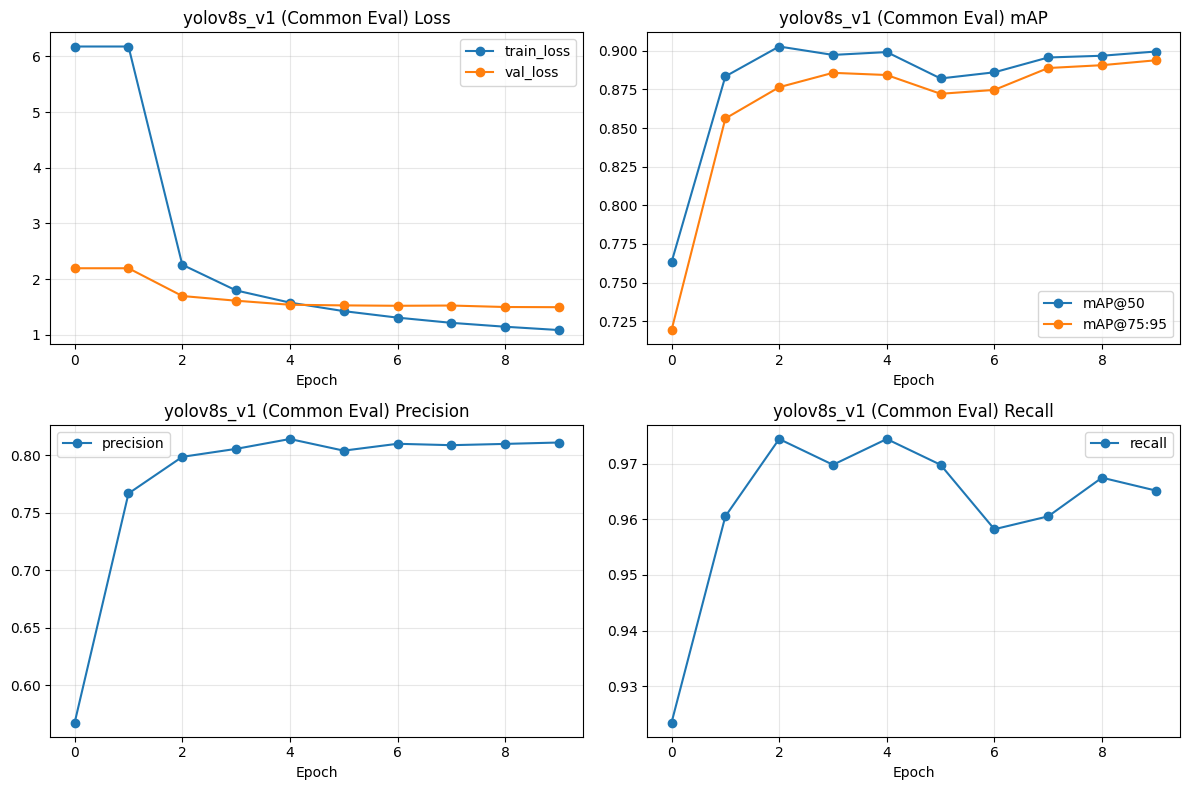

In [24]:
import re

with open(TRAIN_JSON, 'r', encoding='utf-8') as f:
    train_coco = json.load(f)

train_category_ids = sorted({int(ann['category_id']) for ann in train_coco['annotations']})
yolo2cat = {yolo_id: cat_id for yolo_id, cat_id in enumerate(train_category_ids)}

with open(VAL_JSON, 'r', encoding='utf-8') as f:
    val_coco = json.load(f)

filename_to_image_id = {
    Path(img['file_name']).name: int(img['id'])
    for img in val_coco['images']
}

def _extract_epoch_num(path_obj):
    m = re.search(r'epoch(\d+)\.pt$', path_obj.name)
    return int(m.group(1)) if m else 0

results_df = pd.read_csv(TRAIN_HISTORY_CSV) if TRAIN_HISTORY_CSV.exists() else pd.DataFrame()

train_box = _pick_col(results_df, ['train/box_loss']) if len(results_df) else []
train_cls = _pick_col(results_df, ['train/cls_loss']) if len(results_df) else []
train_dfl = _pick_col(results_df, ['train/dfl_loss']) if len(results_df) else []
val_box = _pick_col(results_df, ['val/box_loss']) if len(results_df) else []
val_cls = _pick_col(results_df, ['val/cls_loss']) if len(results_df) else []
val_dfl = _pick_col(results_df, ['val/dfl_loss']) if len(results_df) else []

train_total_losses = [a + b + c for a, b, c in zip(train_box, train_cls, train_dfl)]
val_total_losses = [a + b + c for a, b, c in zip(val_box, val_cls, val_dfl)]

weights_dir = TRAIN_DIR / 'weights'
epoch_ckpts = sorted(weights_dir.glob('epoch*.pt'), key=_extract_epoch_num)

history_common = init_history()
per_epoch_rows = []

if RUN_COMMON_EVAL_EACH_EPOCH and epoch_ckpts:
    eval_targets = [(_extract_epoch_num(ckpt), ckpt) for ckpt in epoch_ckpts]
    print(f'Running common evaluation for {len(eval_targets)} epoch checkpoints...')
else:
    eval_targets = [(EPOCHS, BEST_TARGET)]
    print('Epoch checkpoints missing or loop disabled. Running common eval on best model only.')

for epoch_num, ckpt_path in eval_targets:
    eval_model = YOLO(str(ckpt_path))
    pred_results = eval_model.predict(
        source=str(VAL_IMAGE_DIR),
        imgsz=IMGSZ,
        conf=PREDICT_CONF_FOR_COMMON_EVAL,
        iou=NMS_IOU,
        save=False,
        verbose=False,
    )

    image_ids = []
    for result in pred_results:
        fname = Path(result.path).name
        if fname not in filename_to_image_id:
            raise KeyError(f'Prediction image not found in val JSON metadata: {fname}')
        image_ids.append(filename_to_image_id[fname])

    yolo_predictions = convert_yolo_results(pred_results, image_ids=image_ids)

    mapped_predictions = []
    for pred in yolo_predictions:
        yolo_class = int(pred['category_id'])
        if yolo_class not in yolo2cat:
            continue
        item = dict(pred)
        item['category_id'] = int(yolo2cat[yolo_class])
        mapped_predictions.append(item)

    if len(mapped_predictions) == 0:
        print(f'[WARN] epoch {epoch_num}: mapped_predictions is empty -> set metrics to 0.')
        metrics = {
            'mAP@50': 0.0,
            'mAP@75:95': 0.0,
            'precision': 0.0,
            'recall': 0.0,
            'details': {
                'tp': 0,
                'fp': 0,
                'fn': int(len(val_coco.get('annotations', []))),
                'conf_threshold': CONF_THRESHOLD,
                'pr_iou_threshold': PR_IOU_THRESHOLD,
            },
        }
    else:
        metrics = evaluate_all(
            gt_json_path=str(VAL_JSON),
            predictions=mapped_predictions,
            conf_threshold=CONF_THRESHOLD,
            pr_iou_threshold=PR_IOU_THRESHOLD,
            temp_json_path=str(RESULTS_DIR / f'{MODEL_NAME}_temp_eval_epoch_{epoch_num}.json'),
        )

    idx = max(0, min(epoch_num - 1, len(train_total_losses) - 1)) if len(train_total_losses) else None
    epoch_train_loss = float(train_total_losses[idx]) if idx is not None else None
    epoch_val_loss = float(val_total_losses[idx]) if idx is not None else None

    update_history(
        history_common,
        epoch=int(epoch_num),
        train_loss=epoch_train_loss,
        val_loss=epoch_val_loss,
        metrics=metrics,
    )

    per_epoch_rows.append({
        'epoch': int(epoch_num),
        'checkpoint': str(ckpt_path),
        'num_predictions': len(mapped_predictions),
        'train_loss': epoch_train_loss,
        'val_loss': epoch_val_loss,
        'mAP@50': metrics['mAP@50'],
        'mAP@75:95': metrics['mAP@75:95'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
    })

df_common_hist = pd.DataFrame(per_epoch_rows).sort_values('epoch').reset_index(drop=True)

COMMON_CSV = RESULTS_DIR / f'common_eval_{MODEL_NAME}.csv'
COMMON_JSON = RESULTS_DIR / f'common_eval_{MODEL_NAME}.json'
COMMON_HISTORY_CSV = RESULTS_DIR / f'common_eval_history_{MODEL_NAME}.csv'
COMMON_HISTORY_JSON = RESULTS_DIR / f'common_history_{MODEL_NAME}.json'

if len(df_common_hist):
    best_idx = df_common_hist['mAP@75:95'].astype(float).idxmax()
    best_row = df_common_hist.loc[best_idx].to_dict()
else:
    best_row = {
        'epoch': EPOCHS,
        'checkpoint': str(BEST_TARGET),
        'num_predictions': 0,
        'train_loss': None,
        'val_loss': None,
        'mAP@50': None,
        'mAP@75:95': None,
        'precision': None,
        'recall': None,
    }

common_record = {
    'timestamp': dt.datetime.now().isoformat(),
    'model_name': MODEL_NAME,
    'weights': WEIGHTS,
    'epochs': EPOCHS,
    'imgsz': IMGSZ,
    'batch': BATCH,
    'best_weights_path': str(BEST_TARGET),
    **best_row,
}

pd.DataFrame([{k: v for k, v in common_record.items()}]).to_csv(COMMON_CSV, index=False)
with open(COMMON_JSON, 'w', encoding='utf-8') as f:
    json.dump(common_record, f, ensure_ascii=False, indent=2)

df_common_hist.to_csv(COMMON_HISTORY_CSV, index=False)
save_history(history_common, str(COMMON_HISTORY_JSON))

print(f'Common evaluation CSV: {COMMON_CSV}')
print(f'Common evaluation JSON: {COMMON_JSON}')
print(f'Common history CSV: {COMMON_HISTORY_CSV}')
print(f'Common history JSON: {COMMON_HISTORY_JSON}')

display(pd.DataFrame([common_record]))
if len(df_common_hist):
    display(df_common_hist.tail())

plot_training_history(history_common, title_prefix=f'{MODEL_NAME} (Common Eval)')


# YOLO 기본 평가 (참고용)

- YOLO 공식 보고서 기준 지표
(공통 평가는 위쪽 셀 참고 부탁드립니다.)


Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
Model summary (fused): 73 layers, 11,153,835 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 130.0±18.8 MB/s, size: 146.8 KB)
val: Scanning /content/drive/MyDrive/data/초급_프로젝트/dataset/letterbox_images/val.cache... 139 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 139/139 38.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.4it/s 3.7s0.2ss
                   all        139        431      0.802      0.925      0.902      0.896
Speed: 3.1ms preprocess, 7.1ms inference, 0.0ms loss, 9.6ms postprocess per image
Results saved to /content/drive/MyDrive/pill_detection_project/models/yolo/runs/yolov8s_v1_val
Native evaluation CSV: /content/drive/MyDrive/pill_detection_project/results/yolo/native_eval_yolov8s_v1.csv
Native evaluation JSON: /content/drive/MyDrive/pill_detection_project/results/y

,timestamp,model_name,weights,epochs,imgsz,batch,best_weights_path,train_history_csv,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),fitness
0,2026-03-19T07:24:57.092879,yolov8s_v1,yolov8s.pt,10,800,16,/content/drive/MyDrive/pill_detection_project/...,/content/drive/MyDrive/pill_detection_project/...,0.801916,0.925082,0.901783,0.896313,0.896313


Native history CSV: /content/drive/MyDrive/pill_detection_project/results/yolo/native_history_yolov8s_v1.csv
Native history JSON: /content/drive/MyDrive/pill_detection_project/results/yolo/native_history_yolov8s_v1.json
Training history tail:


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
5,6,195.173,0.13885,0.40781,0.76262,0.75480,0.94002,0.89731,0.89053,0.20486,0.54800,0.76918,0.000066,0.000066,0.000066
6,7,226.982,0.12546,0.32959,0.76071,0.76544,0.92857,0.90108,0.89215,0.19827,0.56073,0.76740,0.000053,0.000053,0.000053
7,8,258.980,0.11343,0.27291,0.75941,0.80863,0.90175,0.89729,0.89270,0.19536,0.53810,0.76639,0.000040,0.000040,0.000040
8,9,291.375,0.10325,0.22536,0.75766,0.80215,0.92470,0.90190,0.89626,0.19243,0.53847,0.76572,0.000027,0.000027,0.000027
9,10,323.437,0.09242,0.20108,0.75608,0.78931,0.92990,0.89343,0.88858,0.19055,0.53103,0.76494,0.000014,0.000014,0.000014


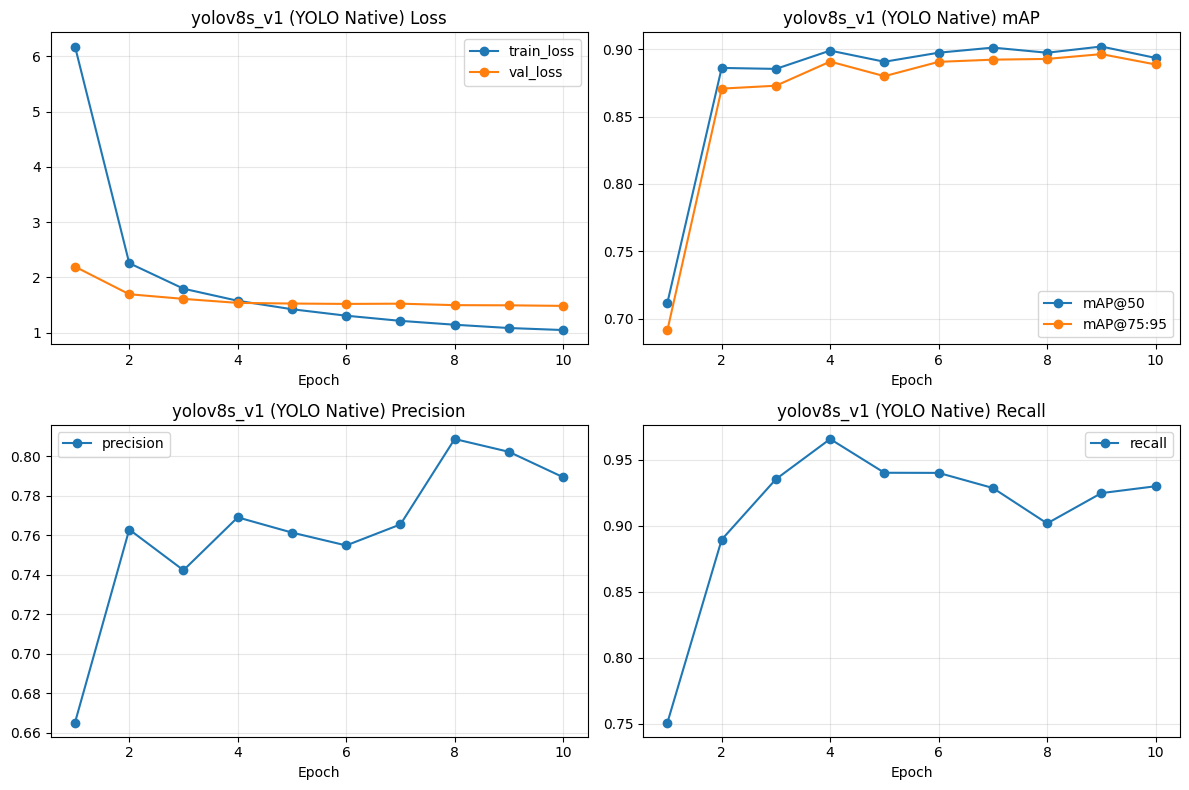

In [25]:
best_model = YOLO(str(BEST_TARGET))

val_result = best_model.val(
    data=str(DATA_YAML),
    split='val',
    imgsz=IMGSZ,
    batch=BATCH,
    project=str(RUNS_DIR),
    name=f'{MODEL_NAME}_val',
    exist_ok=True,
    verbose=False,
)

native_metrics = {}
for key, value in val_result.results_dict.items():
    try:
        native_metrics[key] = float(value)
    except Exception:
        native_metrics[key] = str(value)

native_record = {
    'timestamp': dt.datetime.now().isoformat(),
    'model_name': MODEL_NAME,
    'weights': WEIGHTS,
    'epochs': EPOCHS,
    'imgsz': IMGSZ,
    'batch': BATCH,
    'best_weights_path': str(BEST_TARGET),
    'train_history_csv': str(TRAIN_HISTORY_CSV),
    **native_metrics,
}

df_native = pd.DataFrame([native_record])

NATIVE_CSV = RESULTS_DIR / f'native_eval_{MODEL_NAME}.csv'
NATIVE_JSON = RESULTS_DIR / f'native_eval_{MODEL_NAME}.json'
NATIVE_HISTORY_CSV = RESULTS_DIR / f'native_history_{MODEL_NAME}.csv'
NATIVE_HISTORY_JSON = RESULTS_DIR / f'native_history_{MODEL_NAME}.json'

df_native.to_csv(NATIVE_CSV, index=False)
with open(NATIVE_JSON, 'w', encoding='utf-8') as f:
    json.dump(native_record, f, ensure_ascii=False, indent=2)

print(f'Native evaluation CSV: {NATIVE_CSV}')
print(f'Native evaluation JSON: {NATIVE_JSON}')
display(df_native)

if TRAIN_HISTORY_CSV.exists():
    history_df = pd.read_csv(TRAIN_HISTORY_CSV)
    history_df.to_csv(NATIVE_HISTORY_CSV, index=False)

    yolo_history, _ = build_history_from_yolo_results(TRAIN_HISTORY_CSV)
    save_history(yolo_history, str(NATIVE_HISTORY_JSON))

    print(f'Native history CSV: {NATIVE_HISTORY_CSV}')
    print(f'Native history JSON: {NATIVE_HISTORY_JSON}')
    print('Training history tail:')
    display(history_df.tail())

    # 공통 평가 헬퍼 기반 YOLO 지표/손실 시각화
    plot_training_history(yolo_history, title_prefix=f'{MODEL_NAME} (YOLO Native)')
else:
    print(f'Training history not found: {TRAIN_HISTORY_CSV}')


In [26]:
# 런타임 재연결 상황 로드 점검
common_csv_df = pd.read_csv(COMMON_CSV)
native_csv_df = pd.read_csv(NATIVE_CSV)

with open(COMMON_JSON, 'r', encoding='utf-8') as f:
    common_json_obj = json.load(f)

with open(NATIVE_JSON, 'r', encoding='utf-8') as f:
    native_json_obj = json.load(f)

if 'NATIVE_HISTORY_JSON' in globals() and Path(NATIVE_HISTORY_JSON).exists():
    loaded_history = load_history(str(NATIVE_HISTORY_JSON))
    print(f"Loaded native history epochs: {len(loaded_history.get('epoch', []))}")

print('Reload check passed.')
print(f'Common CSV rows: {len(common_csv_df)}')
print(f'Native CSV rows: {len(native_csv_df)}')
print('Common JSON keys:', sorted(common_json_obj.keys())[:8], '...')
print('Native JSON keys:', sorted(native_json_obj.keys())[:8], '...')


Loaded native history epochs: 10
Reload check passed.
Common CSV rows: 1
Native CSV rows: 1
Common JSON keys: ['batch', 'best_weights_path', 'checkpoint', 'epoch', 'epochs', 'imgsz', 'mAP@50', 'mAP@75:95'] ...
Native JSON keys: ['batch', 'best_weights_path', 'epochs', 'fitness', 'imgsz', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(B)'] ...
